# 02 — Análisis exploratorio de datos

Este notebook analiza los datasets originales de reservas de los dos hoteles. En esta primera etapa se configura el entorno, se cargan los archivos y se valida que ambos compartan el mismo esquema.

## Configuración del entorno

La resolución de la raíz permite ejecutar el notebook tanto desde la raíz del repositorio como desde la carpeta `notebooks`. Si el repositorio no está disponible localmente, la carga puede utilizar las URL Raw de GitHub configuradas más adelante.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Fuerzo a Pandas a mostrar todas las columnas del Dataset
pd.set_option("display.max_columns", None)

In [2]:
def find_project_root(start_path=None):
    """Busca la raíz del repositorio a partir del directorio actual."""
    start = Path(start_path or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw").is_dir():
            return candidate

    return None


PROJECT_ROOT = find_project_root()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw" if PROJECT_ROOT else None

print(f"Raíz del proyecto: {PROJECT_ROOT or 'no disponible localmente'}")

Raíz del proyecto: C:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026


In [3]:
if PROJECT_ROOT is not None:
    project_root_str = str(PROJECT_ROOT)

    if project_root_str not in sys.path:
        sys.path.insert(0, project_root_str)

## Carga de los datasets

La carga prioriza los archivos originales disponibles en `data/raw`. Si no los encuentra, utiliza las URL Raw de GitHub. De esta forma, el mismo notebook podrá ejecutarse dentro del repositorio o en un entorno remoto como Google Colab.

In [4]:
from src.data import load_csv

load_from_URL = True  # Cambiar a False si se desea cargar desde archivos locales

# Defino las URLs de los datasets H1 y H2
H1_URL = "https://raw.githubusercontent.com/Lithium582/Obligatorio2026/refs/heads/main/data/raw/H1.csv"  # Completar con la URL Raw de H1.csv
H2_URL = "https://raw.githubusercontent.com/Lithium582/Obligatorio2026/refs/heads/main/data/raw/H2.csv"  # Completar con la URL Raw de H2.csv

# Defino las rutas locales de los datasets H1 y H2
H1_LOCAL_PATH = RAW_DATA_DIR / "H1.csv" if RAW_DATA_DIR else None
H2_LOCAL_PATH = RAW_DATA_DIR / "H2.csv" if RAW_DATA_DIR else None

if load_from_URL:
    h1_df = load_csv(H1_URL)
    h2_df = load_csv(H2_URL)
else:
    h1_df = load_csv(H1_LOCAL_PATH)
    h2_df = load_csv(H2_LOCAL_PATH)

print(f"H1 cargado")
print(f"H2 cargado")

H1 cargado
H2 cargado


## Validación del esquema

Antes de integrar los hoteles se comprueba que ambos archivos contengan las mismas columnas y en el mismo orden.

In [5]:
h1_columns = list(h1_df.columns)
h2_columns = list(h2_df.columns)

if h1_columns != h2_columns:
    only_in_h1 = sorted(set(h1_columns) - set(h2_columns))
    only_in_h2 = sorted(set(h2_columns) - set(h1_columns))
    raise ValueError(
        "Los datasets no comparten el mismo esquema. "
        f"Sólo en H1: {only_in_h1}. Sólo en H2: {only_in_h2}."
    )

schema_summary = pd.DataFrame(
    {
        "dataset": ["H1", "H2"],
        "rows": [len(h1_df), len(h2_df)],
        "columns": [len(h1_columns), len(h2_columns)],
        "shared_schema": [True, True],
    }
)

display(schema_summary)
display(pd.DataFrame({"column": h1_columns}))

,dataset,rows,columns,shared_schema
0,H1,40060,31,True
1,H2,79330,31,True


,column
0,IsCanceled
1,LeadTime
2,ArrivalDateYear
3,ArrivalDateMonth
4,ArrivalDateWeekNumber
5,ArrivalDateDayOfMonth
6,StaysInWeekendNights
7,StaysInWeekNights
8,Adults
9,Children


## Integración de los datasets

Antes de concatenar los archivos se agrega `HotelType` para conservar el origen de cada reserva. Esta variable distingue los dos hoteles observados, pero no debe interpretarse como una comparación general entre todos los resort hotels y city hotels.

In [6]:
h1_with_hotel = h1_df.copy()
h2_with_hotel = h2_df.copy()

h1_with_hotel.insert(0, "HotelType", "Resort Hotel")
h2_with_hotel.insert(0, "HotelType", "City Hotel")

bookings_df = pd.concat(
    [h1_with_hotel, h2_with_hotel],
    ignore_index=True,
)

### Validación de la integración

Se comprueba que la concatenación conserve todas las reservas y que cada dataset haya recibido el identificador esperado.

In [7]:
expected_rows = len(h1_df) + len(h2_df)
expected_hotel_types = {"Resort Hotel", "City Hotel"}
observed_hotel_types = set(bookings_df["HotelType"].unique())

if len(bookings_df) != expected_rows:
    raise ValueError(
        f"La integración produjo {len(bookings_df)} filas; "
        f"se esperaban {expected_rows}."
    )

if observed_hotel_types != expected_hotel_types:
    raise ValueError(
        "Los identificadores de hotel no coinciden con los esperados: "
        f"{sorted(observed_hotel_types)}."
    )

integration_summary = (
    bookings_df.groupby("HotelType", as_index=False)
    .size()
    .rename(columns={"size": "rows"})
)

display(integration_summary)
display(bookings_df.head())
print(f"Dataset integrado: {bookings_df.shape[0]} filas y {bookings_df.shape[1]} columnas.")

,HotelType,rows
0,City Hotel,79330
1,Resort Hotel,40060


,HotelType,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,Babies,Meal,Country,MarketSegment,DistributionChannel,IsRepeatedGuest,PreviousCancellations,PreviousBookingsNotCanceled,ReservedRoomType,AssignedRoomType,BookingChanges,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NULL,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,NULL,0,Transient,98.0,0,1,Check-Out,2015-07-03


Dataset integrado: 119390 filas y 32 columnas.


## EDA Inicial

### Búsqueda de nulos

Este dataset tiene algunas particularidades
Por ejemplo, muchas columnas tienen el valor "NULL" escrito como texto (esto se ve en el "head", en columnas como "Company"), por lo que como primer paso para limpiarlo debemos eliminar espacios de relleno y después convertir estos textos "NULL" a valores nulos

In [8]:
bookings_df.describe()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,Babies,IsRepeatedGuest,PreviousCancellations,PreviousBookingsNotCanceled,BookingChanges,DaysInWaitingList,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000


In [9]:
null_counts = bookings_df.isna().sum()
null_counts[null_counts > 0].sort_values(ascending=False)

Country     488
Children      4
dtype: int64

In [10]:
text_columns = bookings_df.select_dtypes(include=["object", "string"]).columns

# Elimino los espacios de relleno sin alterar los nulos ya reconocidos.
bookings_df[text_columns] = bookings_df[text_columns].apply(
    lambda column: column.str.strip()
)

# Convierto la categoría textual NULL en un valor nulo real de pandas.
bookings_df[text_columns] = bookings_df[text_columns].replace("NULL", pd.NA)

In [11]:
null_counts = bookings_df.isna().sum()
null_counts[null_counts > 0].sort_values(ascending=False)

Company     112593
Agent        16340
Country        488
Children         4
dtype: int64

### Búsqueda de etiquetas especiales

Además de los nulos reconocidos por pandas, se buscan categorías que podrían representar información ausente o no definida. La coincidencia es exacta y no distingue mayúsculas, minúsculas ni espacios exteriores. Encontrar una etiqueta no implica que deba imputarse: primero debe interpretarse según el significado de la columna.

In [12]:
special_missing_labels = {
    "NA",
    "N/A",
    "N.A.",
    "NONE",
    "NULL",
    "NAN",
    "UNKNOWN",
    "UNDEFINED",
    "NOT APPLICABLE",
    "NOT AVAILABLE",
    "MISSING",
    "?",
}

special_label_records = []

for column in text_columns:
    normalized_values = (
        bookings_df[column]
        .astype("string")
        .str.strip()
        .str.upper()
    )
    label_counts = normalized_values[
        normalized_values.isin(special_missing_labels)
    ].value_counts()

    for label, count in label_counts.items():
        special_label_records.append(
            {
                "column": column,
                "label": label,
                "count": count,
                "percentage": count / len(bookings_df) * 100,
            }
        )

special_labels_summary = pd.DataFrame(special_label_records)

if special_labels_summary.empty:
    print("No se encontraron etiquetas especiales adicionales.")
else:
    display(
        special_labels_summary.sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

,column,label,count,percentage
0,Meal,UNDEFINED,1169,0.979144
1,DistributionChannel,UNDEFINED,5,0.004188
2,MarketSegment,UNDEFINED,2,0.001675


### Reservas sin huéspedes o sin noches

Se buscan reservas cuya composición completa de huéspedes suma cero y reservas que no registran noches de estadía. Para identificar reservas sin personas se exige que `Adults`, `Children` y `Babies` estén informadas; un nulo no se interpreta como cero.

In [13]:
guest_columns = ["Adults", "Children", "Babies"]
night_columns = ["StaysInWeekendNights", "StaysInWeekNights"]

total_guests = bookings_df[guest_columns].sum(
    axis=1,
    min_count=len(guest_columns),
)
total_nights = bookings_df[night_columns].sum(axis=1)

no_guests_mask = total_guests.eq(0)
zero_nights_mask = total_nights.eq(0)

particular_cases_summary = pd.DataFrame(
    {
        "case": [
            "No guests",
            "Zero nights",
            "No guests and zero nights",
        ],
        "rows": [
            no_guests_mask.sum(),
            zero_nights_mask.sum(),
            (no_guests_mask & zero_nights_mask).sum(),
        ],
    }
)
particular_cases_summary["percentage"] = (
    particular_cases_summary["rows"] / len(bookings_df) * 100
)

display(particular_cases_summary)

,case,rows,percentage
0,No guests,180,0.150766
1,Zero nights,715,0.598878
2,No guests and zero nights,70,0.058631


In [14]:
display(
    bookings_df.loc[
        no_guests_mask,
        ["HotelType", *guest_columns, *night_columns, "IsCanceled"],
    ].head(20)
)

display(
    bookings_df.loc[
        zero_nights_mask,
        ["HotelType", *guest_columns, *night_columns, "IsCanceled"],
    ].head(20)
)

,HotelType,Adults,Children,Babies,StaysInWeekendNights,StaysInWeekNights,IsCanceled
2224,Resort Hotel,0,0.0,0,0,3,0
2409,Resort Hotel,0,0.0,0,0,0,0
3181,Resort Hotel,0,0.0,0,1,2,0
3684,Resort Hotel,0,0.0,0,1,4,0
3708,Resort Hotel,0,0.0,0,2,4,0
4127,Resort Hotel,0,0.0,0,0,0,1
9376,Resort Hotel,0,0.0,0,0,0,1
31765,Resort Hotel,0,0.0,0,2,8,0
32029,Resort Hotel,0,0.0,0,0,1,0
32827,Resort Hotel,0,0.0,0,3,9,0


,HotelType,Adults,Children,Babies,StaysInWeekendNights,StaysInWeekNights,IsCanceled
0,Resort Hotel,2,0.0,0,0,0,0
1,Resort Hotel,2,0.0,0,0,0,0
167,Resort Hotel,2,0.0,0,0,0,0
168,Resort Hotel,1,0.0,0,0,0,0
196,Resort Hotel,2,0.0,0,0,0,0
197,Resort Hotel,2,0.0,0,0,0,0
459,Resort Hotel,2,0.0,0,0,0,0
568,Resort Hotel,1,0.0,0,0,0,0
569,Resort Hotel,2,0.0,0,0,0,0
618,Resort Hotel,2,2.0,0,0,0,0


Estas observaciones se mantienen por ahora. Su tratamiento se decidirá después de estudiar si representan errores, cancelaciones administrativas, reservas de uso diurno u otras situaciones válidas del negocio.

## Análisis de valores únicos y categorías

La cardinalidad permite distinguir variables categóricas manejables, identificadores y variables numéricas continuas o discretas. En esta etapa sólo se describen los valores observados: una categoría poco frecuente no se considera errónea automáticamente.

In [15]:
unique_values_summary = pd.DataFrame(
    {
        "dtype": bookings_df.dtypes.astype(str),
        "non_null_rows": bookings_df.notna().sum(),
        "null_rows": bookings_df.isna().sum(),
        "unique_values": bookings_df.nunique(dropna=True),
    }
).sort_values(["unique_values", "null_rows"])

display(unique_values_summary)

,dtype,non_null_rows,null_rows,unique_values
HotelType,str,119390,0,2
IsCanceled,int64,119390,0,2
IsRepeatedGuest,int64,119390,0,2
ArrivalDateYear,int64,119390,0,3
DepositType,str,119390,0,3
ReservationStatus,str,119390,0,3
CustomerType,str,119390,0,4
Babies,int64,119390,0,5
Meal,str,119390,0,5
DistributionChannel,str,119390,0,5


### Distribución de las variables categóricas

Se muestran todas las categorías junto con su frecuencia y porcentaje. Los nulos se presentan explícitamente para no confundirlos con categorías de baja frecuencia.

In [16]:
categorical_columns = bookings_df.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

for column in categorical_columns:
    category_counts = (
        bookings_df[column]
        .value_counts(dropna=False)
        .rename_axis(column)
        .reset_index(name="rows")
    )
    category_counts["percentage"] = (
        category_counts["rows"] / len(bookings_df) * 100
    )

    print(f"{column}: {bookings_df[column].nunique(dropna=True)} categorías no nulas")
    display(category_counts)

HotelType: 2 categorías no nulas


,HotelType,rows,percentage
0,City Hotel,79330,66.446101
1,Resort Hotel,40060,33.553899


ArrivalDateMonth: 12 categorías no nulas


,ArrivalDateMonth,rows,percentage
0,August,13877,11.623252
1,July,12661,10.604741
2,May,11791,9.876037
3,October,11160,9.347517
4,April,11089,9.288048
5,June,10939,9.162409
6,September,10508,8.801407
7,March,9794,8.203367
8,February,8068,6.757685
9,November,6794,5.690594


Meal: 5 categorías no nulas


...

,CustomerType,rows,percentage
0,Transient,89613,75.059050
1,Transient-Party,25124,21.043638
2,Contract,4076,3.414021
3,Group,577,0.483290


ReservationStatus: 3 categorías no nulas


,ReservationStatus,rows,percentage
0,Check-Out,75166,62.958372
1,Canceled,43017,36.030656
2,No-Show,1207,1.010972


ReservationStatusDate: 926 categorías no nulas


,ReservationStatusDate,rows,percentage
0,2015-10-21,1461,1.223721
1,2015-07-06,805,0.674261
2,2016-11-25,790,0.661697
3,2015-01-01,763,0.639082
4,2016-01-18,625,0.523494
...,...,...,...
921,2015-04-21,1,0.000838
922,2015-03-13,1,0.000838
923,2015-03-29,1,0.000838
924,2015-04-27,1,0.000838


### Categorías poco frecuentes

Como apoyo para la inspección se identifican categorías que representan menos del 0,1 % de las reservas. El umbral es exploratorio: no implica que deban agruparse ni eliminarse. En variables como `Country`, una categoría infrecuente puede seguir siendo válida.

In [17]:
rare_category_threshold = 0.001
rare_category_records = []

for column in categorical_columns:
    counts = bookings_df[column].value_counts(dropna=False)

    for value, count in counts.items():
        proportion = count / len(bookings_df)
        if proportion < rare_category_threshold:
            rare_category_records.append(
                {
                    "column": column,
                    "value": value,
                    "rows": count,
                    "percentage": proportion * 100,
                }
            )

rare_categories_summary = pd.DataFrame(rare_category_records)

if rare_categories_summary.empty:
    print("No se encontraron categorías por debajo del umbral elegido.")
else:
    display(
        rare_categories_summary
        .sort_values(["column", "rows", "value"], na_position="first")
        .reset_index(drop=True)
    )

,column,value,rows,percentage
0,Agent,114,1,0.000838
1,Agent,117,1,0.000838
2,Agent,144,1,0.000838
3,Agent,158,1,0.000838
4,Agent,165,1,0.000838
...,...,...,...,...
1122,ReservationStatusDate,2017-07-14,119,0.099673
1123,ReservationStatusDate,2017-07-30,119,0.099673
1124,ReservationStatusDate,2017-08-20,119,0.099673
1125,ReservedRoomType,L,6,0.005026


### Posibles categorías duplicadas por formato

Aunque ya se eliminaron espacios exteriores, se comprueba si una misma etiqueta aparece escrita con diferencias de mayúsculas o minúsculas. Este diagnóstico evita generar columnas separadas para una misma categoría durante el preprocesamiento.

In [18]:
format_collision_records = []

for column in categorical_columns:
    non_null_values = bookings_df[column].dropna().astype(str)
    normalized_groups = (
        pd.DataFrame(
            {
                "original": non_null_values,
                "normalized": non_null_values.str.strip().str.casefold(),
            }
        )
        .groupby("normalized")["original"]
        .agg(lambda values: sorted(set(values)))
    )

    for normalized_value, variants in normalized_groups.items():
        if len(variants) > 1:
            format_collision_records.append(
                {
                    "column": column,
                    "normalized_value": normalized_value,
                    "observed_variants": variants,
                }
            )

format_collisions_summary = pd.DataFrame(format_collision_records)

if format_collisions_summary.empty:
    print("No se encontraron categorías duplicadas por diferencias de formato.")
else:
    display(format_collisions_summary)

No se encontraron categorías duplicadas por diferencias de formato.


## Próximos pasos: rangos y valores atípicos

El siguiente bloque analizará las variables numéricas según su significado. No se aplicará una única regla automática a todas las columnas: los identificadores, conteos, importes, proporciones y variables temporales requieren criterios diferentes. Primero se revisarán mínimos, máximos, percentiles y distribuciones; después se distinguirán valores extremos válidos de posibles errores de calidad.

## Análisis de rangos y valores atípicos

Las variables se separan según su significado. Los indicadores binarios, las variables de calendario y los identificadores no deben analizarse como medidas continuas. El diagnóstico se concentra en duraciones, cantidades e importes; ningún criterio implica eliminar observaciones automáticamente.

In [19]:
binary_columns = ["IsCanceled", "IsRepeatedGuest"]
calendar_columns = [
    "ArrivalDateYear", "ArrivalDateMonth",
    "ArrivalDateWeekNumber", "ArrivalDateDayOfMonth",
]
identifier_columns = ["Agent", "Company"]
numeric_analysis_columns = [
    "LeadTime", "StaysInWeekendNights", "StaysInWeekNights",
    "Adults", "Children", "Babies",
    "PreviousCancellations", "PreviousBookingsNotCanceled",
    "BookingChanges", "DaysInWaitingList", "ADR",
    "RequiredCarParkingSpaces", "TotalOfSpecialRequests",
]

missing_numeric_columns = sorted(
    set(numeric_analysis_columns) - set(bookings_df.columns)
)
if missing_numeric_columns:
    raise ValueError(f"Faltan columnas esperadas: {missing_numeric_columns}")

### Resumen robusto

Se comparan los extremos con varios percentiles para distinguir valores frecuentes de observaciones aisladas. Los ceros y negativos se contabilizan porque su validez depende del significado de cada variable.

In [20]:
numeric_data = bookings_df[numeric_analysis_columns]
percentiles = numeric_data.quantile(
    [0.00, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00]
).T
percentiles.columns = [
    "min", "p01", "p05", "p25", "median",
    "p75", "p95", "p99", "max",
]
numeric_ranges_summary = percentiles.assign(
    null_rows=numeric_data.isna().sum(),
    zero_rows=numeric_data.eq(0).sum(),
    negative_rows=numeric_data.lt(0).sum(),
)
numeric_ranges_summary["zero_percentage"] = (
    numeric_ranges_summary["zero_rows"] / len(bookings_df) * 100
)
numeric_ranges_summary["negative_percentage"] = (
    numeric_ranges_summary["negative_rows"] / len(bookings_df) * 100
)
display(numeric_ranges_summary.round(3))

,min,p01,p05,p25,median,p75,p95,p99,max,null_rows,zero_rows,negative_rows,zero_percentage,negative_percentage
LeadTime,0.00,0.0,0.0,18.00,69.000,160.0,320.0,444.0,737.0,0,6345,0,5.315,0.000
StaysInWeekendNights,0.00,0.0,0.0,0.00,1.000,2.0,2.0,4.0,19.0,0,51998,0,43.553,0.000
StaysInWeekNights,0.00,0.0,0.0,1.00,2.000,3.0,5.0,10.0,50.0,0,7645,0,6.403,0.000
Adults,0.00,1.0,1.0,2.00,2.000,2.0,3.0,3.0,55.0,0,403,0,0.338,0.000
Children,0.00,0.0,0.0,0.00,0.000,0.0,1.0,2.0,10.0,4,110796,0,92.802,0.000
Babies,0.00,0.0,0.0,0.00,0.000,0.0,0.0,0.0,10.0,0,118473,0,99.232,0.000
PreviousCancellations,0.00,0.0,0.0,0.00,0.000,0.0,1.0,1.0,26.0,0,112906,0,94.569,0.000
PreviousBookingsNotCanceled,0.00,0.0,0.0,0.00,0.000,0.0,0.0,3.0,72.0,0,115770,0,96.968,0.000
BookingChanges,0.00,0.0,0.0,0.00,0.000,0.0,1.0,3.0,21.0,0,101314,0,84.860,0.000
DaysInWaitingList,0.00,0.0,0.0,0.00,0.000,0.0,0.0,75.0,391.0,0,115692,0,96.903,0.000


### Intervalo intercuartílico ampliado

Se cuenta cuántas observaciones quedan fuera de 1,5 veces el rango intercuartílico. Es una descripción de la asimetría, no una clasificación automática de errores. En conteos con muchos ceros incluso un valor positivo puede quedar señalado.

In [21]:
iqr_records = []
for column in numeric_analysis_columns:
    values = bookings_df[column].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outside_mask = values.lt(lower_bound) | values.gt(upper_bound)
    iqr_records.append({
        "column": column,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outside_rows": outside_mask.sum(),
        "outside_percentage": outside_mask.mean() * 100,
    })

iqr_outliers_summary = pd.DataFrame(iqr_records).set_index("column")
display(iqr_outliers_summary.round(3))

,lower_bound,upper_bound,outside_rows,outside_percentage
column,,,,
LeadTime,-195.000,373.000,3005,2.517
StaysInWeekendNights,-3.000,5.000,265,0.222
StaysInWeekNights,-2.000,6.000,3354,2.809
Adults,2.000,2.000,29710,24.885
Children,0.000,0.000,8590,7.195
Babies,0.000,0.000,917,0.768
PreviousCancellations,0.000,0.000,6484,5.431
PreviousBookingsNotCanceled,0.000,0.000,3620,3.032
BookingChanges,0.000,0.000,18076,15.140


### Controles de dominio

Se comprueban condiciones difíciles de justificar por la definición de las variables. Por ahora no se imponen límites superiores: un valor grande puede ser válido y debe inspeccionarse en contexto.

In [22]:
non_negative_columns = [
    "LeadTime", "StaysInWeekendNights", "StaysInWeekNights",
    "Adults", "Children", "Babies",
    "PreviousCancellations", "PreviousBookingsNotCanceled",
    "BookingChanges", "DaysInWaitingList",
    "RequiredCarParkingSpaces", "TotalOfSpecialRequests",
]
domain_records = [
    {"check": f"Negative {column}", "rows": bookings_df[column].lt(0).sum()}
    for column in non_negative_columns
]
domain_records.extend([
    {"check": "Negative ADR", "rows": bookings_df["ADR"].lt(0).sum()},
    {"check": "Invalid IsCanceled",
     "rows": (~bookings_df["IsCanceled"].isin([0, 1])).sum()},
    {"check": "Invalid IsRepeatedGuest",
     "rows": (~bookings_df["IsRepeatedGuest"].isin([0, 1])).sum()},
])
domain_checks_summary = pd.DataFrame(domain_records)
domain_checks_summary["percentage"] = (
    domain_checks_summary["rows"] / len(bookings_df) * 100
)
display(domain_checks_summary)

,check,rows,percentage
0,Negative LeadTime,0,0.000000
1,Negative StaysInWeekendNights,0,0.000000
2,Negative StaysInWeekNights,0,0.000000
3,Negative Adults,0,0.000000
4,Negative Children,0,0.000000
5,Negative Babies,0,0.000000
6,Negative PreviousCancellations,0,0.000000
7,Negative PreviousBookingsNotCanceled,0,0.000000
8,Negative BookingChanges,0,0.000000
9,Negative DaysInWaitingList,0,0.000000


### Distribuciones numéricas

Los histogramas se limitan visualmente al percentil 99 para evitar que unos pocos extremos compriman la masa principal. Esos extremos no se eliminan y siguen registrados en el resumen anterior.

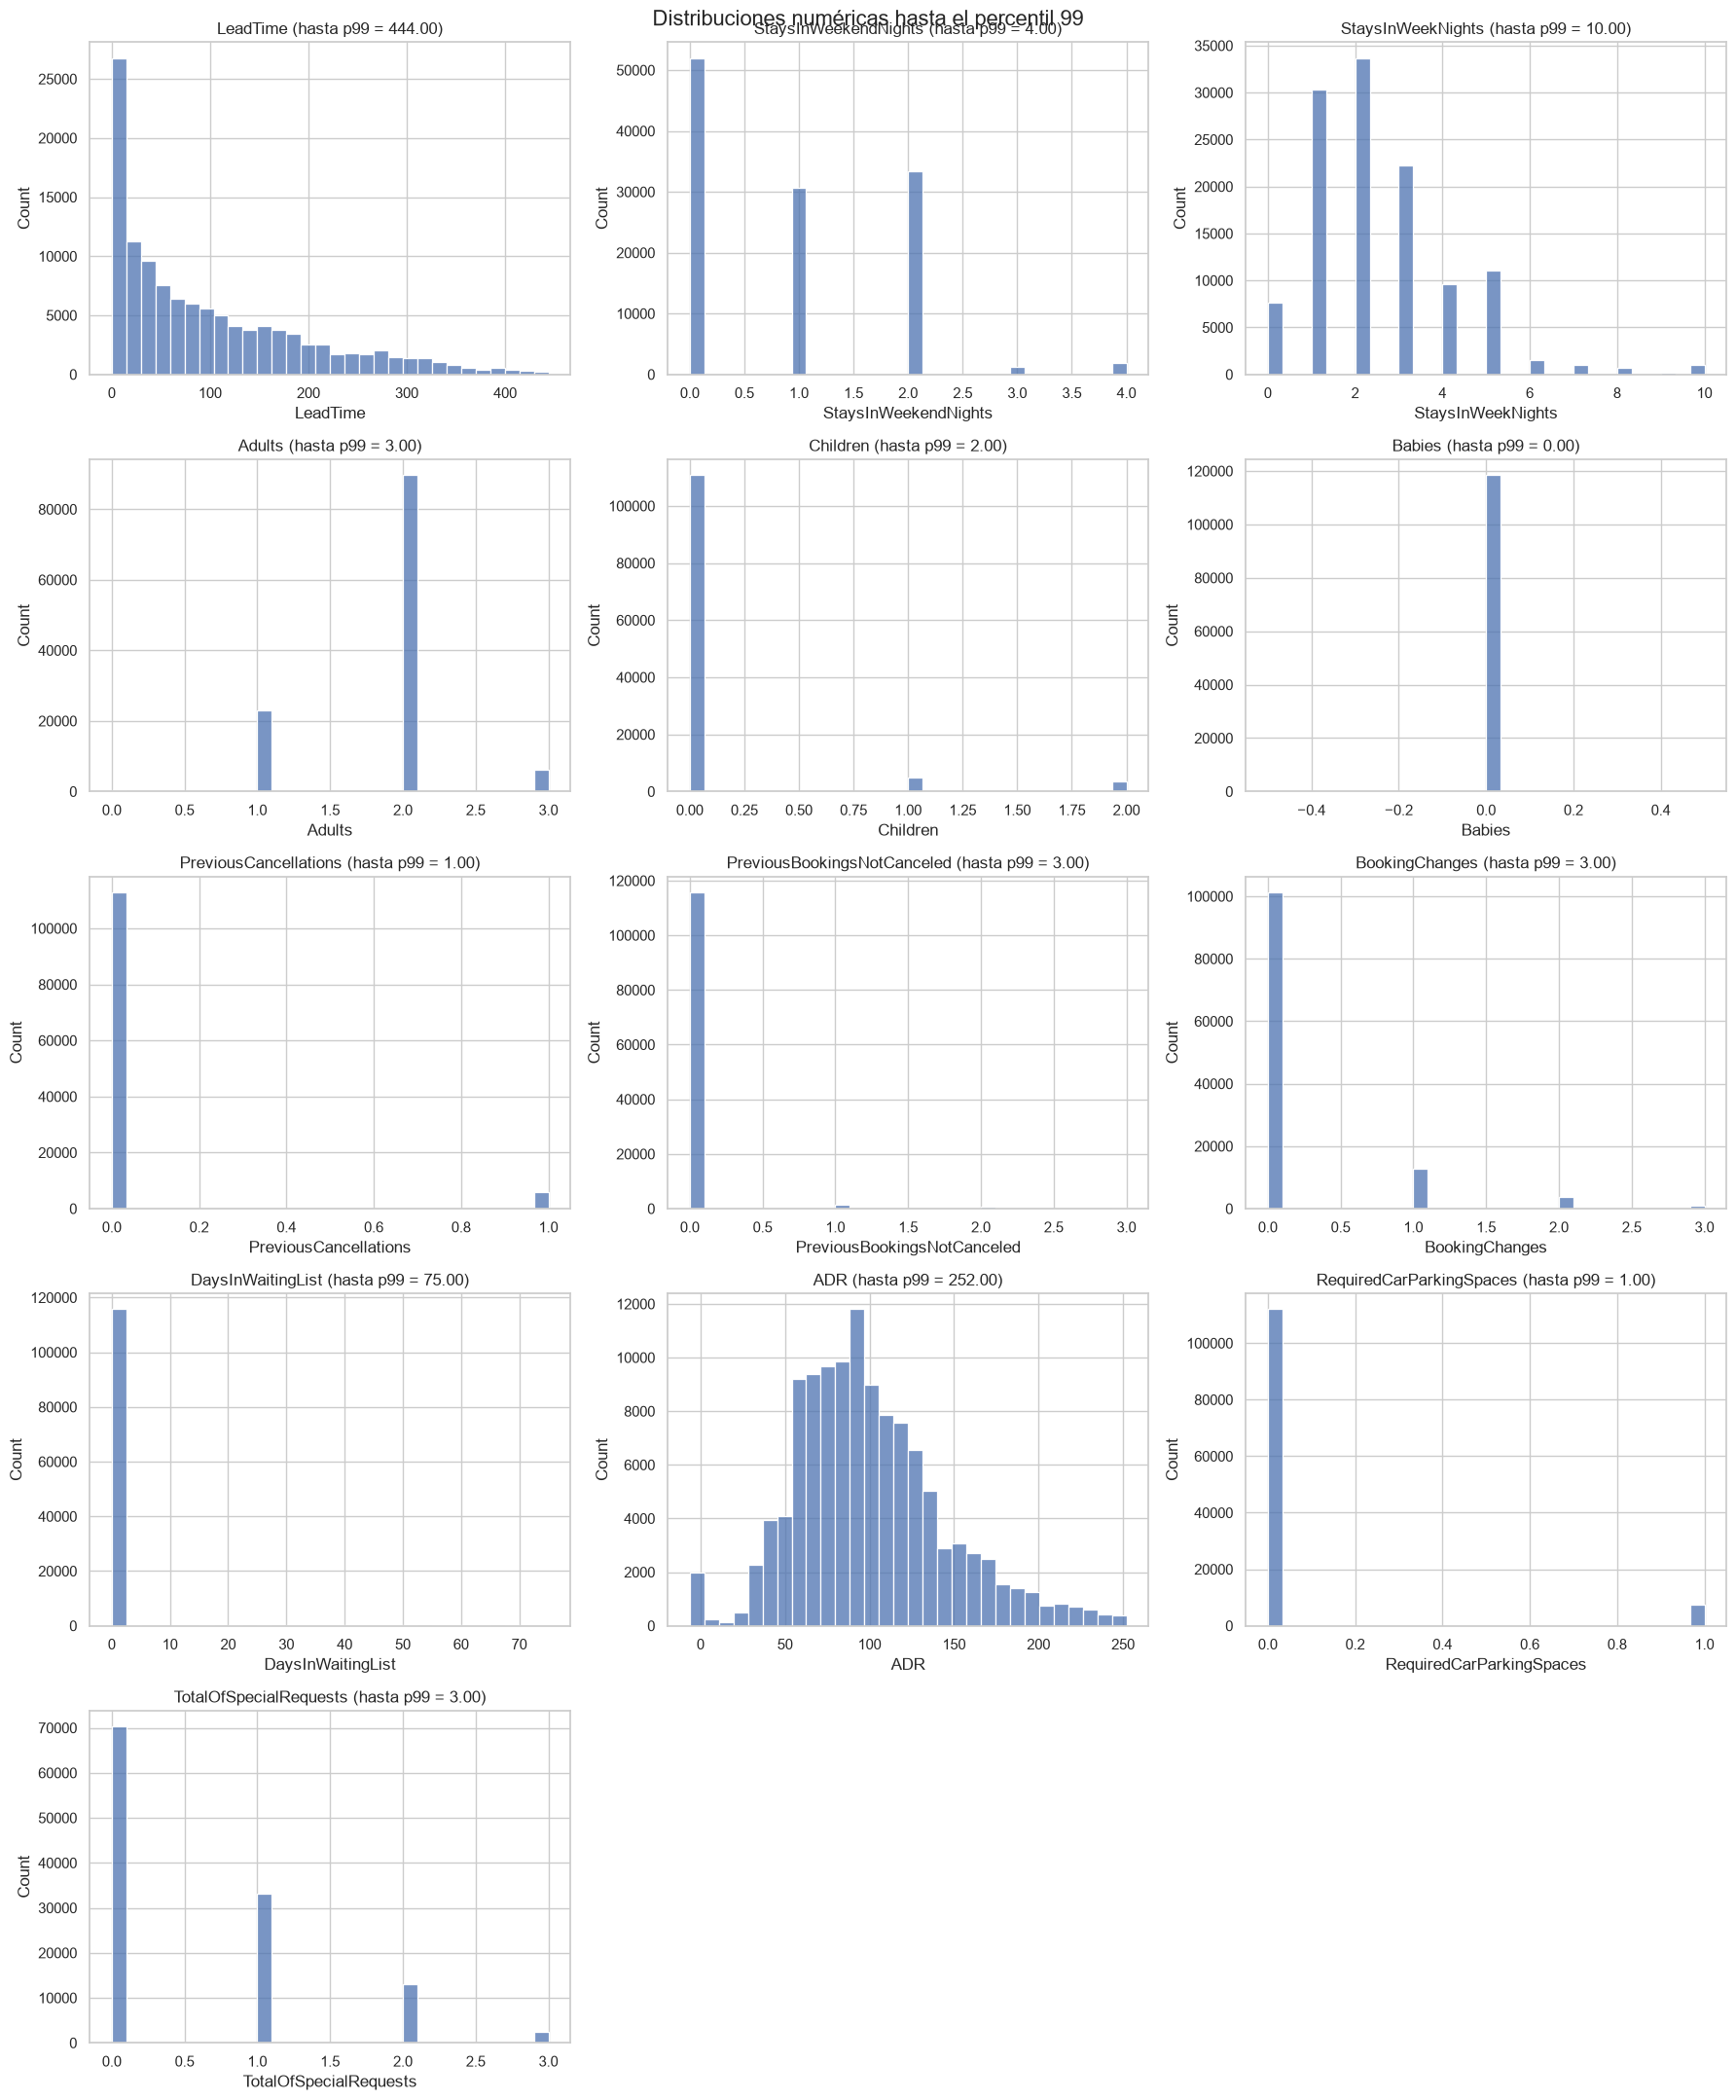

In [23]:
figure, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()

for axis, column in zip(axes, numeric_analysis_columns):
    upper_visual_limit = bookings_df[column].quantile(0.99)
    visible_values = bookings_df.loc[
        bookings_df[column].le(upper_visual_limit), column
    ].dropna()
    sns.histplot(visible_values, bins=30, ax=axis)
    axis.set_title(f"{column} (hasta p99 = {upper_visual_limit:.2f})")

for axis in axes[len(numeric_analysis_columns):]:
    axis.set_visible(False)

figure.suptitle("Distribuciones numéricas hasta el percentil 99", fontsize=16)
plt.tight_layout()
plt.show()

### Inspección de casos extremos

Se muestran los mayores valores de las variables con rangos más amplios y cualquier `ADR` negativo para estudiar reservas concretas sin alterar los datos.

In [24]:
extreme_inspection_columns = [
    "ADR", "LeadTime", "StaysInWeekendNights",
    "StaysInWeekNights", "Adults", "Children", "Babies",
    "DaysInWaitingList",
]
context_columns = [
    "HotelType", "IsCanceled", "ReservationStatus",
    "ArrivalDateYear", "ArrivalDateMonth",
]

for column in extreme_inspection_columns:
    print(f"Valores más altos de {column}")
    display(bookings_df.nlargest(10, column)[[*context_columns, column]])

negative_adr_rows = bookings_df.loc[
    bookings_df["ADR"].lt(0),
    [*context_columns, "ADR", "Adults", "Children", "Babies"],
]
if not negative_adr_rows.empty:
    print("Reservas con ADR negativo")
    display(negative_adr_rows)

Valores más altos de ADR


,HotelType,IsCanceled,ReservationStatus,ArrivalDateYear,ArrivalDateMonth,ADR
48515,City Hotel,1,Canceled,2016,March,5400.00
111403,City Hotel,0,Check-Out,2017,May,510.00
15083,Resort Hotel,0,Check-Out,2015,July,508.00
103912,City Hotel,0,Check-Out,2016,December,451.50
13142,Resort Hotel,1,Canceled,2017,August,450.00
13391,Resort Hotel,1,Canceled,2017,August,437.00
39155,Resort Hotel,0,Check-Out,2017,August,426.25
39568,Resort Hotel,0,Check-Out,2017,August,402.00
39118,Resort Hotel,0,Check-Out,2017,July,397.38
13323,Resort Hotel,1,Canceled,2017,August,392.00


Valores más altos de LeadTime


,HotelType,IsCanceled,ReservationStatus,ArrivalDateYear,ArrivalDateMonth,LeadTime
1,Resort Hotel,0,Check-Out,2015,July,737
4182,Resort Hotel,0,Check-Out,2016,February,709
65231,City Hotel,1,Canceled,2017,March,629
65235,City Hotel,1,Canceled,2017,March,629
65237,City Hotel,1,Canceled,2017,March,629
65238,City Hotel,1,Canceled,2017,March,629
65239,City Hotel,1,Canceled,2017,March,629
65240,City Hotel,1,Canceled,2017,March,629
65241,City Hotel,1,Canceled,2017,March,629
65242,City Hotel,1,Canceled,2017,March,629


Valores más altos de StaysInWeekendNights


...

,HotelType,IsCanceled,ReservationStatus,ArrivalDateYear,ArrivalDateMonth,Babies
46619,City Hotel,0,Check-Out,2016,January,10
78656,City Hotel,0,Check-Out,2015,October,9
264,Resort Hotel,0,Check-Out,2015,July,2
6719,Resort Hotel,1,Canceled,2016,June,2
7896,Resort Hotel,1,Canceled,2016,September,2
14556,Resort Hotel,0,Check-Out,2016,December,2
16677,Resort Hotel,0,Check-Out,2015,September,2
29906,Resort Hotel,0,Check-Out,2016,November,2
33332,Resort Hotel,0,Check-Out,2017,February,2
37302,Resort Hotel,0,Check-Out,2017,June,2


Valores más altos de DaysInWaitingList


,HotelType,IsCanceled,ReservationStatus,ArrivalDateYear,ArrivalDateMonth,DaysInWaitingList
58152,City Hotel,1,Canceled,2016,October,391
58153,City Hotel,1,Canceled,2016,October,391
58154,City Hotel,1,Canceled,2016,October,391
58155,City Hotel,1,Canceled,2016,October,391
58157,City Hotel,1,Canceled,2016,October,391
58158,City Hotel,1,Canceled,2016,October,391
58159,City Hotel,1,Canceled,2016,October,391
58160,City Hotel,1,Canceled,2016,October,391
58161,City Hotel,1,Canceled,2016,October,391
58167,City Hotel,1,Canceled,2016,October,391


Reservas con ADR negativo


,HotelType,IsCanceled,ReservationStatus,ArrivalDateYear,ArrivalDateMonth,ADR,Adults,Children,Babies
14969,Resort Hotel,0,Check-Out,2017,March,-6.38,2,0.0,0


### Análisis contextual de cantidades extremas de huéspedes

Los máximos de `Adults`, `Children` y `Babies` están separados de los valores habituales. Se inspeccionan usando umbrales basados en esos saltos observados, no como límites universales de validez. El objetivo es evaluar si corresponden a reservas grupales coherentes, patrones repetidos o posibles errores de registro.

In [25]:
guest_extreme_masks = {
    "Adults > 10": bookings_df["Adults"].gt(10),
    "Children > 3": bookings_df["Children"].gt(3),
    "Babies > 2": bookings_df["Babies"].gt(2),
}

guest_extremes_summary = pd.DataFrame(
    {
        "case": guest_extreme_masks.keys(),
        "rows": [mask.sum() for mask in guest_extreme_masks.values()],
    }
)
guest_extremes_summary["percentage"] = (
    guest_extremes_summary["rows"] / len(bookings_df) * 100
)
display(guest_extremes_summary)

,case,rows,percentage
0,Adults > 10,12,0.010051
1,Children > 3,1,0.000838
2,Babies > 2,2,0.001675


In [26]:
guest_context_columns = [
    "HotelType", "ArrivalDateYear", "ArrivalDateMonth",
    "Adults", "Children", "Babies",
    "StaysInWeekendNights", "StaysInWeekNights",
    "ReservedRoomType", "AssignedRoomType",
    "MarketSegment", "DistributionChannel",
    "CustomerType", "Agent", "Company",
    "ADR", "IsCanceled", "ReservationStatus",
]

for case, mask in guest_extreme_masks.items():
    print(case)
    display(
        bookings_df.loc[mask, guest_context_columns]
        .sort_values(["Adults", "Children", "Babies"], ascending=False)
    )

Adults > 10


,HotelType,ArrivalDateYear,ArrivalDateMonth,Adults,Children,Babies,StaysInWeekendNights,StaysInWeekNights,ReservedRoomType,AssignedRoomType,MarketSegment,DistributionChannel,CustomerType,Agent,Company,ADR,IsCanceled,ReservationStatus
2173,Resort Hotel,2015,October,55,0.0,0,2,0,A,A,Direct,Direct,Group,NaN,NaN,0.0,1,Canceled
1643,Resort Hotel,2015,September,50,0.0,0,1,2,A,A,Direct,Direct,Group,NaN,NaN,0.0,1,Canceled
1539,Resort Hotel,2015,September,40,0.0,0,0,3,A,A,Direct,Direct,Group,NaN,NaN,0.0,1,Canceled
1917,Resort Hotel,2015,September,27,0.0,0,1,3,A,A,Direct,Direct,Group,NaN,NaN,0.0,1,Canceled
1962,Resort Hotel,2015,September,27,0.0,0,1,3,A,A,Direct,Direct,Group,NaN,NaN,0.0,1,Canceled
1587,Resort Hotel,2015,September,26,0.0,0,2,5,A,A,Offline TA/TO,TA/TO,Group,96,NaN,0.0,1,Canceled
1752,Resort Hotel,2015,September,26,0.0,0,2,5,A,A,Offline TA/TO,TA/TO,Group,96,NaN,0.0,1,Canceled
1884,Resort Hotel,2015,September,26,0.0,0,2,5,A,A,Offline TA/TO,TA/TO,Group,96,NaN,0.0,1,Canceled
2003,Resort Hotel,2015,September,26,0.0,0,2,5,A,A,Offline TA/TO,TA/TO,Group,96,NaN,0.0,1,Canceled
2164,Resort Hotel,2015,October,26,0.0,0,2,5,A,A,Offline TA/TO,TA/TO,Group,96,NaN,0.0,1,Canceled


Children > 3


,HotelType,ArrivalDateYear,ArrivalDateMonth,Adults,Children,Babies,StaysInWeekendNights,StaysInWeekNights,ReservedRoomType,AssignedRoomType,MarketSegment,DistributionChannel,CustomerType,Agent,Company,ADR,IsCanceled,ReservationStatus
328,Resort Hotel,2015,July,2,10.0,0,4,10,D,D,Offline TA/TO,TA/TO,Contract,8,NaN,133.16,1,No-Show


Babies > 2


,HotelType,ArrivalDateYear,ArrivalDateMonth,Adults,Children,Babies,StaysInWeekendNights,StaysInWeekNights,ReservedRoomType,AssignedRoomType,MarketSegment,DistributionChannel,CustomerType,Agent,Company,ADR,IsCanceled,ReservationStatus
46619,City Hotel,2016,January,2,0.0,10,0,2,D,D,Online TA,TA/TO,Transient,9,NaN,84.45,0,Check-Out
78656,City Hotel,2015,October,1,0.0,9,2,1,A,B,Corporate,Corporate,Transient-Party,95,NaN,95.00,0,Check-Out


### Patrones compartidos entre los casos extremos

Las reservas grupales pueden aparecer como varias filas relacionadas. Para reconocer esos patrones se resumen las variables de contexto y se buscan combinaciones repetidas sin asumir que sean filas duplicadas.

In [27]:
all_guest_extremes_mask = np.logical_or.reduce(
    list(guest_extreme_masks.values())
)
guest_extreme_rows = bookings_df.loc[all_guest_extremes_mask].copy()
guest_extreme_rows["TotalGuests"] = guest_extreme_rows[
    ["Adults", "Children", "Babies"]
].sum(axis=1, min_count=3)
guest_extreme_rows["TotalNights"] = guest_extreme_rows[
    ["StaysInWeekendNights", "StaysInWeekNights"]
].sum(axis=1)

pattern_columns = [
    "HotelType", "ArrivalDateYear", "ArrivalDateMonth",
    "MarketSegment", "DistributionChannel", "CustomerType",
    "Adults", "Children", "Babies", "IsCanceled",
]
guest_extreme_patterns = (
    guest_extreme_rows.groupby(pattern_columns, dropna=False)
    .size()
    .rename("rows")
    .reset_index()
    .sort_values("rows", ascending=False)
)

display(guest_extreme_patterns)
display(
    guest_extreme_rows[[
        "Adults", "Children", "Babies",
        "TotalGuests", "TotalNights", "ADR",
    ]].describe()
)

,HotelType,ArrivalDateYear,ArrivalDateMonth,MarketSegment,DistributionChannel,CustomerType,Adults,Children,Babies,IsCanceled,rows
9,Resort Hotel,2015,September,Offline TA/TO,TA/TO,Group,26,0.0,0,1,4
3,Resort Hotel,2015,October,Direct,Direct,Group,20,0.0,0,1,2
6,Resort Hotel,2015,September,Direct,Direct,Group,27,0.0,0,1,2
0,City Hotel,2015,October,Corporate,Corporate,Transient-Party,1,0.0,9,0,1
1,City Hotel,2016,January,Online TA,TA/TO,Transient,2,0.0,10,0,1
2,Resort Hotel,2015,July,Offline TA/TO,TA/TO,Contract,2,10.0,0,1,1
5,Resort Hotel,2015,October,Offline TA/TO,TA/TO,Group,26,0.0,0,1,1
4,Resort Hotel,2015,October,Direct,Direct,Group,55,0.0,0,1,1
7,Resort Hotel,2015,September,Direct,Direct,Group,40,0.0,0,1,1
8,Resort Hotel,2015,September,Direct,Direct,Group,50,0.0,0,1,1


,Adults,Children,Babies,TotalGuests,TotalNights,ADR
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,24.933333,0.666667,1.266667,26.866667,5.600000,20.840667
std,15.691065,2.581989,3.348063,12.883360,3.112188,44.218118
min,1.000000,0.000000,0.000000,10.000000,2.000000,0.000000
25%,20.000000,0.000000,0.000000,20.000000,3.000000,0.000000
50%,26.000000,0.000000,0.000000,26.000000,7.000000,0.000000
75%,27.000000,0.000000,0.000000,27.000000,7.000000,0.000000
max,55.000000,10.000000,10.000000,55.000000,14.000000,133.160000


Los casos se mantienen sin cambios durante el EDA. A partir de su contexto se documentará si parecen reservas grupales plausibles o valores difíciles de justificar; cualquier tratamiento se decidirá más adelante y se comparará dentro del proceso de modelado.

## Conclusiones preliminares de calidad y rangos

### Valores ausentes y categorías especiales

Después de eliminar espacios exteriores y convertir la etiqueta textual `NULL` en un nulo real, las columnas con valores ausentes son `Company`, `Agent`, `Country` y `Children`. La ausencia de `Agent` y `Company` parece ser principalmente estructural: estas variables identifican a la agencia o empresa asociada con la reserva y no necesariamente aplican a todas las operaciones. Por ello, no corresponde interpretar automáticamente sus nulos como información desconocida ni imputarlos con la categoría más frecuente.

También se encontraron las categorías `Undefined` en `Meal`, `MarketSegment` y `DistributionChannel`. En `Meal`, la documentación del dataset relaciona `Undefined` y `SC` con reservas sin paquete de comidas, aunque ambas etiquetas se conservarán separadas durante el EDA para comprobar su comportamiento antes de considerar una agrupación. Los casos `Undefined` de segmento y canal son muy escasos y quedan registrados para su tratamiento posterior.

### Reservas sin huéspedes o sin noches

Se identificaron 180 reservas sin huéspedes registrados, 715 con cero noches y 70 que cumplen ambas condiciones. La mayoría figura con estado `Check-Out`, por lo que no pueden explicarse únicamente como reservas canceladas o incompletas. Las estadías de cero noches podrían corresponder a uso diurno o registros administrativos; las reservas sin huéspedes resultan más difíciles de interpretar. Se mantienen durante el EDA y su impacto se evaluará posteriormente mediante análisis de sensibilidad.

### Rangos y valores atípicos

Las distribuciones de duraciones y conteos son fuertemente asimétricas y contienen muchos ceros. Como consecuencia, el criterio del rango intercuartílico señala numerosos valores que no son necesariamente errores. No se utilizará este criterio como una regla automática de eliminación. Los valores altos de `LeadTime`, noches de estadía y días en lista de espera son inusuales, pero resultan operativamente posibles.

`ADR` presenta dos observaciones particularmente anómalas: un valor negativo de -6,38 y un máximo de 5400. El máximo está ampliamente separado del resto de la distribución: el percentil 99 es 252 y el segundo valor más alto es 510. El dataset no permite determinar si se trata de errores de registro, ajustes comerciales o situaciones excepcionales. Ambos casos se conservan y se considerarán alternativas de tratamiento durante Feature Engineering, especialmente para los modelos sensibles al escalado y a valores extremos.

### Cantidades extremas de huéspedes

Las 12 reservas con más de 10 adultos pertenecen al `Resort Hotel`, están clasificadas como `Group`, tienen `ADR` igual a cero y fueron canceladas. Varias comparten fecha, duración, agencia y cantidad de adultos, lo que aporta coherencia con la interpretación de reservas grupales o bloques de habitaciones. Estos valores altos de `Adults` se consideran plausibles y se conservarán. Sin embargo, representan solamente el 0,01 % del dataset y no permiten generalizar que todas las reservas grupales grandes tengan el mismo comportamiento.

El único caso con 10 niños podría representar una reserva colectiva, aunque no está clasificado como `Group`. Los dos registros con 9 y 10 bebés son más difíciles de justificar: corresponden a reservas con uno o dos adultos y finalizaron en `Check-Out`. Se mantienen por ahora, pero quedan señalados como posibles errores de registro para evaluar su tratamiento posteriormente.

Estas conclusiones describen la evidencia encontrada y servirán como entrada para Feature Analysis y Feature Engineering. En este notebook no se eliminan observaciones ni se definen todavía reglas de imputación o transformación.

## Revisión de duplicados y patrones repetidos

El dataset no contiene un identificador único de reserva. Por ese motivo, dos filas idénticas pueden ser duplicados técnicos, pero también reservas diferentes pertenecientes a un mismo grupo o realizadas bajo las mismas condiciones. El análisis cuantifica las coincidencias sin eliminarlas.

### Filas completamente duplicadas

Se consideran todas las columnas disponibles, incluido el resultado final. Se informa tanto la cantidad de filas que participan en grupos repetidos como la cantidad que quedaría al conservar una sola aparición por combinación.

In [28]:
exact_duplicate_mask = bookings_df.duplicated(keep=False)
exact_redundant_mask = bookings_df.duplicated(keep="first")

exact_duplicates_summary = pd.DataFrame(
    {
        "measure": [
            "Rows participating in exact duplicate groups",
            "Rows removed if one copy per group were retained",
            "Rows remaining after a hypothetical deduplication",
        ],
        "rows": [
            exact_duplicate_mask.sum(),
            exact_redundant_mask.sum(),
            len(bookings_df) - exact_redundant_mask.sum(),
        ],
    }
)
exact_duplicates_summary["percentage_of_dataset"] = (
    exact_duplicates_summary["rows"] / len(bookings_df) * 100
)
display(exact_duplicates_summary)

,measure,rows,percentage_of_dataset
0,Rows participating in exact duplicate groups,40165,33.641846
1,Rows removed if one copy per group were retained,31994,26.797889
2,Rows remaining after a hypothetical deduplication,87396,73.202111


In [29]:
exact_duplicate_groups = (
    bookings_df.loc[exact_duplicate_mask]
    .groupby(bookings_df.columns.tolist(), dropna=False)
    .size()
    .rename("repetitions")
    .reset_index()
    .sort_values("repetitions", ascending=False)
)

exact_group_size_summary = (
    exact_duplicate_groups["repetitions"]
    .value_counts()
    .sort_index()
    .rename_axis("repetitions_per_combination")
    .reset_index(name="combinations")
)
display(exact_group_size_summary)
display(exact_duplicate_groups.head(10))

,repetitions_per_combination,combinations
0,2,5034
1,3,969
2,4,497
3,5,275
4,6,171
...,...,...
67,100,1
68,101,1
69,109,1
70,150,1


,HotelType,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,Babies,Meal,Country,MarketSegment,DistributionChannel,IsRepeatedGuest,PreviousCancellations,PreviousBookingsNotCanceled,ReservedRoomType,AssignedRoomType,BookingChanges,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate,repetitions
5407,City Hotel,1,277,2016,November,46,7,1,2,2,0.0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,Non Refund,NaN,NaN,0,Transient,100.0,0,0,Canceled,2016-04-04,180
4183,City Hotel,1,68,2016,February,8,17,0,2,2,0.0,0,BB,PRT,Groups,TA/TO,0,1,0,A,A,0,Non Refund,37,NaN,0,Transient,75.0,0,0,Canceled,2016-01-06,150
5077,City Hotel,1,188,2016,June,25,15,0,2,1,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,Non Refund,119,NaN,39,Transient,130.0,0,0,Canceled,2016-01-18,109
4881,City Hotel,1,158,2016,May,22,24,0,2,1,0.0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,Non Refund,37,NaN,31,Transient,130.0,0,0,Canceled,2016-01-18,101
3852,City Hotel,1,34,2015,December,50,8,0,2,1,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,1,0,A,A,0,Non Refund,19,NaN,0,Transient,90.0,0,0,Canceled,2015-11-17,100
4874,City Hotel,1,156,2017,April,17,26,0,3,2,0.0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,Non Refund,37,NaN,0,Transient,100.0,0,0,Canceled,2016-11-21,99
3794,City Hotel,1,28,2017,March,9,2,0,3,2,0.0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,Non Refund,NaN,NaN,0,Transient,95.0,0,0,Canceled,2017-02-02,99
3908,City Hotel,1,38,2017,January,2,14,0,1,1,0.0,0,BB,PRT,Corporate,Corporate,0,0,0,A,A,0,Non Refund,NaN,67,0,Transient,75.0,0,0,Canceled,2016-12-07,99
4207,City Hotel,1,71,2016,June,25,14,0,3,1,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,Non Refund,236,NaN,0,Transient,120.0,0,0,Canceled,2016-04-27,89
5527,City Hotel,1,305,2016,November,45,4,1,2,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,Non Refund,21,NaN,0,Transient,89.0,0,0,Canceled,2016-02-01,85


### Predictores coincidentes y resultados diferentes

Para aproximar el problema desde el momento de predicción se excluyen `IsCanceled`, `ReservationStatus` y `ReservationStatusDate`. Se buscan reservas que comparten todos los predictores registrados y se comprueba si dentro de una misma combinación aparecen resultados de cancelación diferentes. Esto permite observar que una coincidencia de variables no identifica necesariamente una única reserva.

In [30]:
outcome_columns = ["IsCanceled", "ReservationStatus", "ReservationStatusDate"]
predictor_columns = [
    column for column in bookings_df.columns if column not in outcome_columns
]
predictor_duplicate_mask = bookings_df.duplicated(
    subset=predictor_columns, keep=False
)
predictor_redundant_mask = bookings_df.duplicated(
    subset=predictor_columns, keep="first"
)

predictor_groups = (
    bookings_df.loc[predictor_duplicate_mask]
    .groupby(predictor_columns, dropna=False)
    .agg(
        rows=("IsCanceled", "size"),
        cancellation_values=("IsCanceled", "nunique"),
        cancellation_rate=("IsCanceled", "mean"),
        status_values=("ReservationStatus", "nunique"),
        status_date_values=("ReservationStatusDate", "nunique"),
    )
    .reset_index()
)
conflicting_predictor_groups = predictor_groups.loc[
    predictor_groups["cancellation_values"].gt(1)
]

predictor_duplicates_summary = pd.DataFrame(
    {
        "measure": [
            "Rows participating in repeated predictor combinations",
            "Repeated rows beyond the first predictor combination",
            "Repeated predictor combinations",
            "Predictor combinations with different targets",
            "Rows in predictor combinations with different targets",
        ],
        "rows_or_groups": [
            predictor_duplicate_mask.sum(),
            predictor_redundant_mask.sum(),
            len(predictor_groups),
            len(conflicting_predictor_groups),
            conflicting_predictor_groups["rows"].sum(),
        ],
    }
)
display(predictor_duplicates_summary)

,measure,rows_or_groups
0,Rows participating in repeated predictor combi...,40754
1,Repeated rows beyond the first predictor combi...,32517
2,Repeated predictor combinations,8237
3,Predictor combinations with different targets,265
4,Rows in predictor combinations with different ...,1812


In [31]:
conflicting_group_examples = (
    conflicting_predictor_groups
    .sort_values(["rows", "status_date_values"], ascending=False)
    .head(10)
)
display(conflicting_group_examples)

,HotelType,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,Babies,Meal,Country,MarketSegment,DistributionChannel,IsRepeatedGuest,PreviousCancellations,PreviousBookingsNotCanceled,ReservedRoomType,AssignedRoomType,BookingChanges,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,rows,cancellation_values,cancellation_rate,status_values,status_date_values
3757,City Hotel,134,2017,February,8,25,0,1,1,0.0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,No Deposit,30,NaN,0,Transient-Party,75.00,0,0,107,2,0.476636,3,3
4199,City Hotel,164,2015,October,40,2,0,2,1,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,19,NaN,0,Transient-Party,100.00,0,0,52,2,0.115385,2,4
2066,City Hotel,55,2016,April,15,6,0,1,2,0.0,0,HB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,56,NaN,0,Transient-Party,104.00,0,0,43,2,0.046512,2,2
4201,City Hotel,164,2015,October,40,2,0,2,1,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,D,0,No Deposit,19,NaN,0,Transient-Party,100.00,0,0,38,2,0.078947,2,2
6681,Resort Hotel,40,2017,January,3,16,1,2,1,0.0,0,Undefined,PRT,Groups,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Transient-Party,55.00,0,0,37,2,0.216216,2,6
5484,City Hotel,316,2016,May,22,26,0,3,2,0.0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,No Deposit,30,NaN,0,Transient-Party,110.00,0,0,34,2,0.029412,2,2
2129,City Hotel,57,2016,June,24,10,1,2,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,6,NaN,0,Transient-Party,90.67,0,1,28,2,0.071429,2,2
4242,City Hotel,168,2015,September,37,11,0,2,2,0.0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,No Deposit,1,NaN,0,Transient-Party,60.00,0,0,26,2,0.423077,2,3
700,City Hotel,12,2015,July,29,18,2,2,2,0.0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,No Deposit,1,NaN,0,Transient-Party,62.00,0,0,26,2,0.615385,2,2
3534,City Hotel,122,2016,April,16,15,0,2,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,151,NaN,56,Transient-Party,85.00,0,0,24,2,0.333333,2,2


### Patrones comerciales repetidos

Finalmente se agrupan variables que describen el contexto de llegada, huéspedes y condiciones generales de la reserva. Estas coincidencias son patrones operativos, no duplicados: es esperable que muchas personas reserven bajo configuraciones similares.

In [32]:
business_pattern_columns = [
    "HotelType", "ArrivalDateYear", "ArrivalDateMonth",
    "ArrivalDateWeekNumber", "ArrivalDateDayOfMonth",
    "Adults", "Children", "Babies",
    "StaysInWeekendNights", "StaysInWeekNights",
    "Meal", "MarketSegment", "DistributionChannel",
    "ReservedRoomType", "DepositType", "CustomerType",
]
business_patterns = (
    bookings_df.groupby(business_pattern_columns, dropna=False)
    .agg(
        rows=("IsCanceled", "size"),
        cancellation_rate=("IsCanceled", "mean"),
        distinct_agents=("Agent", "nunique"),
        distinct_companies=("Company", "nunique"),
    )
    .reset_index()
    .sort_values("rows", ascending=False)
)
display(business_patterns.head(20))

,HotelType,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,Adults,Children,Babies,StaysInWeekendNights,StaysInWeekNights,Meal,MarketSegment,DistributionChannel,ReservedRoomType,DepositType,CustomerType,rows,cancellation_rate,distinct_agents,distinct_companies
16300,City Hotel,2016,November,46,7,2,0.0,0,1,2,BB,Groups,TA/TO,A,Non Refund,Transient,210,1.000000,1,0
942,City Hotel,2015,December,50,8,1,0.0,0,0,2,BB,Offline TA/TO,TA/TO,A,Non Refund,Transient,160,1.000000,1,0
329,City Hotel,2015,August,33,14,2,0.0,0,0,2,HB,Offline TA/TO,TA/TO,A,No Deposit,Transient-Party,155,0.658065,1,0
9250,City Hotel,2016,February,8,17,2,0.0,0,0,2,BB,Groups,TA/TO,A,Non Refund,Transient,150,1.000000,1,0
3897,City Hotel,2015,September,38,18,2,0.0,0,0,2,HB,Offline TA/TO,TA/TO,A,Non Refund,Transient-Party,125,1.000000,1,0
2809,City Hotel,2015,October,42,16,2,0.0,0,0,2,HB,Offline TA/TO,TA/TO,A,Non Refund,Transient-Party,122,1.000000,1,0
21367,City Hotel,2017,April,17,26,2,0.0,0,0,3,BB,Groups,TA/TO,A,Non Refund,Transient,120,1.000000,2,0
31039,City Hotel,2017,May,20,15,1,0.0,0,1,2,BB,Groups,TA/TO,A,Non Refund,Transient,120,1.000000,0,0
9647,City Hotel,2016,February,10,28,1,0.0,0,2,1,BB,Offline TA/TO,TA/TO,A,No Deposit,Transient-Party,119,0.865546,1,0
24288,City Hotel,2017,February,8,25,1,0.0,0,0,1,BB,Groups,TA/TO,A,No Deposit,Transient-Party,117,0.504274,1,0


La presencia de coincidencias se documenta como una limitación de identificación. Antes de decidir una deduplicación será necesario analizar el tamaño de los grupos, la existencia de resultados contradictorios y su relación con reservas grupales. El EDA conserva todas las filas.

## Influencia de las repeticiones sobre la cancelación

Se compara el comportamiento de las filas que aparecen una sola vez con el de aquellas que pertenecen a una combinación completamente repetida. Esta separación no afirma que las reservas repetidas sean copias inválidas: permite medir cuánto influyen los bloques coincidentes sobre la distribución del target.

In [33]:
duplicate_comparison_df = bookings_df.copy()
duplicate_comparison_df["RepetitionGroup"] = np.where(
    exact_duplicate_mask,
    "Exact repeated combination",
    "Unique combination",
)

duplicate_target_summary = (
    duplicate_comparison_df.groupby("RepetitionGroup")
    .agg(
        rows=("IsCanceled", "size"),
        cancellations=("IsCanceled", "sum"),
        cancellation_rate=("IsCanceled", "mean"),
    )
    .reset_index()
)
duplicate_target_summary["dataset_percentage"] = (
    duplicate_target_summary["rows"] / len(bookings_df) * 100
)
duplicate_target_summary["cancellation_share"] = (
    duplicate_target_summary["cancellations"]
    / bookings_df["IsCanceled"].sum() * 100
)
display(duplicate_target_summary)

,RepetitionGroup,rows,cancellations,cancellation_rate,dataset_percentage,cancellation_share
0,Exact repeated combination,40165,23451,0.583867,33.641846,53.027768
1,Unique combination,79225,20773,0.262203,66.358154,46.972232


### Comparación por contexto comercial

La tasa se desglosa por variables centrales para comprobar si la diferencia se debe únicamente a que las repeticiones se concentran en determinados hoteles, segmentos o condiciones de depósito.

In [34]:
duplicate_comparison_columns = [
    "HotelType", "DepositType", "MarketSegment", "CustomerType"
]

for column in duplicate_comparison_columns:
    comparison = (
        duplicate_comparison_df.groupby([column, "RepetitionGroup"], dropna=False)
        .agg(
            rows=("IsCanceled", "size"),
            cancellation_rate=("IsCanceled", "mean"),
        )
        .reset_index()
    )
    comparison["within_category_percentage"] = (
        comparison["rows"]
        / comparison.groupby(column, dropna=False)["rows"].transform("sum")
        * 100
    )
    print(column)
    display(comparison)

HotelType


,HotelType,RepetitionGroup,rows,cancellation_rate,within_category_percentage
0,City Hotel,Exact repeated combination,31748,0.613172,40.020169
1,City Hotel,Unique combination,47582,0.286558,59.979831
2,Resort Hotel,Exact repeated combination,8417,0.473328,21.010984
3,Resort Hotel,Unique combination,31643,0.225579,78.989016


DepositType


,DepositType,RepetitionGroup,rows,cancellation_rate,within_category_percentage
0,No Deposit,Exact repeated combination,25773,0.355605,24.629925
1,No Deposit,Unique combination,78868,0.260296,75.370075
2,Non Refund,Exact repeated combination,14316,0.996927,98.142181
3,Non Refund,Unique combination,271,0.819188,1.857819
4,Refundable,Exact repeated combination,76,0.184211,46.913580
5,Refundable,Unique combination,86,0.255814,53.086420


MarketSegment


,MarketSegment,RepetitionGroup,rows,cancellation_rate,within_category_percentage
0,Aviation,Exact repeated combination,19,0.684211,8.016878
1,Aviation,Unique combination,218,0.178899,91.983122
2,Complementary,Exact repeated combination,75,0.200000,10.094213
3,Complementary,Unique combination,668,0.122754,89.905787
4,Corporate,Exact repeated combination,1474,0.379919,27.837583
5,Corporate,Unique combination,3821,0.113059,72.162417
6,Direct,Exact repeated combination,1405,0.238434,11.145486
7,Direct,Unique combination,11201,0.142755,88.854514
8,Groups,Exact repeated combination,16713,0.695267,84.362223
9,Groups,Unique combination,3098,0.153970,15.637777


CustomerType


,CustomerType,RepetitionGroup,rows,cancellation_rate,within_category_percentage
0,Contract,Exact repeated combination,1188,0.709596,29.146222
1,Contract,Unique combination,2888,0.145083,70.853778
2,Group,Exact repeated combination,57,0.122807,9.878683
3,Group,Unique combination,520,0.100000,90.121317
4,Transient,Exact repeated combination,22209,0.776892,24.783235
5,Transient,Unique combination,67404,0.285740,75.216765
6,Transient-Party,Exact repeated combination,16711,0.319969,66.514090
7,Transient-Party,Unique combination,8413,0.123856,33.485910


### Tamaño de la combinación repetida

Se asigna a cada fila el número de veces que aparece su combinación exacta. Luego se compara la cancelación por intervalos de tamaño para saber si los bloques más grandes presentan un comportamiento especialmente diferente.

In [35]:
exact_group_ids = bookings_df.groupby(
    bookings_df.columns.tolist(), dropna=False, sort=False
).ngroup()
exact_group_sizes = exact_group_ids.map(exact_group_ids.value_counts())

duplicate_comparison_df["ExactGroupId"] = exact_group_ids
duplicate_comparison_df["ExactGroupSize"] = exact_group_sizes
duplicate_comparison_df["ExactGroupSizeBand"] = pd.cut(
    exact_group_sizes,
    bins=[0, 1, 2, 5, 10, 25, 50, np.inf],
    labels=["1", "2", "3-5", "6-10", "11-25", "26-50", ">50"],
)

duplicate_size_summary = (
    duplicate_comparison_df.groupby("ExactGroupSizeBand", observed=True)
    .agg(
        rows=("IsCanceled", "size"),
        exact_combinations=("ExactGroupId", "nunique"),
        cancellation_rate=("IsCanceled", "mean"),
    )
    .reset_index()
)
duplicate_size_summary["dataset_percentage"] = (
    duplicate_size_summary["rows"] / len(bookings_df) * 100
)
display(duplicate_size_summary)

,ExactGroupSizeBand,rows,exact_combinations,cancellation_rate,dataset_percentage
0,1,79225,79225,0.262203,66.358154
1,2,10068,5034,0.341677,8.432867
2,3-5,6270,1741,0.378150,5.251696
3,6-10,4722,605,0.493011,3.955105
4,11-25,9688,567,0.760219,8.114582
5,26-50,5798,175,0.774060,4.856353
6,>50,3619,49,0.955789,3.031242


### Comparación hipotética con una versión deduplicada

Esta simulación conserva una sola fila por combinación exacta únicamente para medir el cambio en la distribución. No reemplaza `bookings_df` ni constituye todavía una decisión de preparación.

In [36]:
hypothetical_deduplicated_df = bookings_df.drop_duplicates().copy()

deduplication_effect_summary = pd.DataFrame(
    {
        "dataset": ["Original", "One row per exact combination"],
        "rows": [len(bookings_df), len(hypothetical_deduplicated_df)],
        "cancellations": [
            bookings_df["IsCanceled"].sum(),
            hypothetical_deduplicated_df["IsCanceled"].sum(),
        ],
        "cancellation_rate": [
            bookings_df["IsCanceled"].mean(),
            hypothetical_deduplicated_df["IsCanceled"].mean(),
        ],
    }
)
display(deduplication_effect_summary)

deduplication_by_hotel = pd.concat(
    [
        bookings_df.groupby("HotelType")["IsCanceled"]
        .agg(rows="size", cancellation_rate="mean")
        .assign(dataset="Original"),
        hypothetical_deduplicated_df.groupby("HotelType")["IsCanceled"]
        .agg(rows="size", cancellation_rate="mean")
        .assign(dataset="One row per exact combination"),
    ]
).reset_index()
display(deduplication_by_hotel)

,dataset,rows,cancellations,cancellation_rate
0,Original,119390,44224,0.370416
1,One row per exact combination,87396,24025,0.274898


,HotelType,rows,cancellation_rate,dataset
0,City Hotel,79330,0.417270,Original
1,Resort Hotel,40060,0.277634,Original
2,City Hotel,53428,0.300386,One row per exact combination
3,Resort Hotel,33968,0.234809,One row per exact combination


La comparación permite cuantificar el efecto de las repeticiones, pero no resuelve por sí sola si representan observaciones válidas. La decisión posterior deberá considerar tanto la unidad de análisis —cada reserva— como el riesgo de que combinaciones idénticas aparezcan simultáneamente en entrenamiento y validación.

## Coincidencias según el momento de predicción

La definición de una reserva repetida depende de la información disponible cuando se calcula el riesgo. Se comparan dos escenarios. El primero representa la creación de la reserva y excluye campos que pueden conocerse o modificarse posteriormente. El segundo representa una fotografía operativa más cercana a la llegada e incorpora esos campos, aunque el dataset no permite conocer con precisión cuándo alcanzaron su valor registrado.

### Escenarios considerados

**Creación de la reserva:** se excluyen el target, el estado final, la fecha del estado, la habitación finalmente asignada, los cambios acumulados y los días finales en lista de espera. Esta es la firma más conservadora para evitar información futura.

**Momento operativo previo a la llegada:** se excluyen únicamente el target y sus variables de resultado. Se permite utilizar `AssignedRoomType`, `BookingChanges` y `DaysInWaitingList` como una fotografía operativa. Este escenario sólo sería válido si el hotel pudiera garantizar que esos valores ya están disponibles al ejecutar el modelo.

In [37]:
result_columns = [
    "IsCanceled", "ReservationStatus", "ReservationStatusDate"
]
post_booking_columns = [
    "AssignedRoomType", "BookingChanges", "DaysInWaitingList"
]

prediction_moment_columns = {
    "Booking creation": [
        column for column in bookings_df.columns
        if column not in [*result_columns, *post_booking_columns]
    ],
    "Pre-arrival operational snapshot": [
        column for column in bookings_df.columns
        if column not in result_columns
    ],
}

display(
    pd.DataFrame(
        {
            "prediction_moment": prediction_moment_columns.keys(),
            "signature_columns": prediction_moment_columns.values(),
            "column_count": [
                len(columns) for columns in prediction_moment_columns.values()
            ],
        }
    )
)

,prediction_moment,signature_columns,column_count
0,Booking creation,"[HotelType, LeadTime, ArrivalDateYear, Arrival...",26
1,Pre-arrival operational snapshot,"[HotelType, LeadTime, ArrivalDateYear, Arrival...",29


In [38]:
prediction_moment_records = []
prediction_moment_group_ids = {}

for moment, signature_columns in prediction_moment_columns.items():
    group_ids = bookings_df.groupby(
        signature_columns, dropna=False, sort=False
    ).ngroup()
    group_sizes = group_ids.map(group_ids.value_counts())
    repeated_mask = group_sizes.gt(1)

    group_target_summary = (
        pd.DataFrame(
            {
                "group_id": group_ids,
                "IsCanceled": bookings_df["IsCanceled"],
            }
        )
        .groupby("group_id")
        .agg(
            rows=("IsCanceled", "size"),
            target_values=("IsCanceled", "nunique"),
            cancellation_rate=("IsCanceled", "mean"),
        )
    )
    repeated_groups = group_target_summary.loc[
        group_target_summary["rows"].gt(1)
    ]
    conflicting_groups = repeated_groups.loc[
        repeated_groups["target_values"].gt(1)
    ]

    prediction_moment_group_ids[moment] = group_ids
    prediction_moment_records.append(
        {
            "prediction_moment": moment,
            "signature_columns": len(signature_columns),
            "total_groups": len(group_target_summary),
            "repeated_groups": len(repeated_groups),
            "rows_in_repeated_groups": repeated_mask.sum(),
            "repeated_rows_percentage": repeated_mask.mean() * 100,
            "largest_group": group_sizes.max(),
            "conflicting_groups": len(conflicting_groups),
            "rows_in_conflicting_groups": conflicting_groups["rows"].sum(),
        }
    )

prediction_moment_summary = pd.DataFrame(prediction_moment_records)
display(prediction_moment_summary)

,prediction_moment,signature_columns,total_groups,repeated_groups,rows_in_repeated_groups,repeated_rows_percentage,largest_group,conflicting_groups,rows_in_conflicting_groups
0,Booking creation,26,85034,8515,42871,35.908368,180,302,2209
1,Pre-arrival operational snapshot,29,86873,8237,40754,34.135187,180,265,1812


### Cancelación de combinaciones únicas y repetidas por escenario

Se comprueba si la asociación entre repetición y cancelación se mantiene al definir la firma con información disponible en cada momento.

In [39]:
prediction_moment_target_records = []

for moment, group_ids in prediction_moment_group_ids.items():
    group_sizes = group_ids.map(group_ids.value_counts())
    repetition_label = np.where(
        group_sizes.gt(1), "Repeated signature", "Unique signature"
    )
    moment_comparison = (
        pd.DataFrame(
            {
                "repetition_status": repetition_label,
                "IsCanceled": bookings_df["IsCanceled"],
            }
        )
        .groupby("repetition_status")
        .agg(
            rows=("IsCanceled", "size"),
            cancellation_rate=("IsCanceled", "mean"),
        )
        .reset_index()
    )
    moment_comparison.insert(0, "prediction_moment", moment)
    prediction_moment_target_records.append(moment_comparison)

prediction_moment_target_summary = pd.concat(
    prediction_moment_target_records, ignore_index=True
)
display(prediction_moment_target_summary)

,prediction_moment,repetition_status,rows,cancellation_rate
0,Booking creation,Repeated signature,42871,0.562945
1,Booking creation,Unique signature,76519,0.262549
2,Pre-arrival operational snapshot,Repeated signature,40754,0.586372
3,Pre-arrival operational snapshot,Unique signature,78636,0.258495


Para una evaluación conservadora, la firma correspondiente a la creación de la reserva es la candidata inicial para mantener observaciones relacionadas dentro del mismo fold. La firma definitiva deberá revisarse después de establecer formalmente el momento de intervención y seleccionar las variables admisibles para el modelo.